In [1]:
import os
import math
from datetime import datetime
from pathlib import Path
from typing import List, Union, Tuple
import json

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import pandas as pd

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torch_geometric.nn as geom_nn
from torch_geometric.data import Data, Dataset as GeomDataset
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, GATConv

RDLogger.DisableLog('rdApp.warning')

In [2]:
# --- Configuration & Versioning ---
DATA_VERSION = "v3.0_205"
DATA_DESCRIPTION = "CHEMBL205 EGFR kinase domain only, strict binding filter, median dedup, std<1.0."
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")

BASE_DIR = Path(r"C:\Users\User\Desktop\spark_airflow\chembl\dags\data")
INPUT_FILE = BASE_DIR / "dataset_full_processed_205.parquet"

OUTPUT_DIR = BASE_DIR / "gold" / f"version_{DATA_VERSION}_{TIMESTAMP}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GOLD_DIR = BASE_DIR / "gold"

# MLflow Setup
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("ChEMBL_EDA_Preprocessing")

pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_width_chars(5000)

polars.config.Config

In [3]:
# INSPECTION FUNCTIONS
def inspect_basic_stats(df: pl.DataFrame):
    print(f"Shape: {df.shape}")
    print(df.glimpse())
    print("-" * 30)
    print("Descriptive Stats:")
    print(df.describe())

def check_missing_values(df: pl.DataFrame):
    null_counts = df.null_count()
    cols_with_nulls = [col for col in df.columns if null_counts[col][0] > 0]
    if cols_with_nulls:
        print("Missing Values:")
        print(null_counts.select(cols_with_nulls))
    else:
        print("No missing values found.")
    print("-" * 30)

def plot_missing_values(df: pl.DataFrame):
    null_counts_df = df.null_count().to_pandas()
    null_counts = null_counts_df.melt(var_name="column", value_name="n_nulls")
    null_counts["percent"] = (null_counts["n_nulls"] / df.height) * 100
    null_counts = null_counts[null_counts["n_nulls"] > 0].sort_values("percent", ascending=False)
    
    if not null_counts.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(x="percent", y="column", data=null_counts, palette="Reds_r")
        plt.title("Missing Values (%)")
        plt.show()

Shape: (1381, 49)
Rows: 1381
Columns: 49
$ action_type                      <struct[3]> None, None, None, None, None, None, None, None, None, None
$ activity_comment                       <str> None, None, None, None, None, None, None, None, None, None
$ activity_id                            <i64> 32829, 36538, 38973, 42481, 42491, 44937, 44945, 46040, 46046, 47359
$ activity_properties       <list[struct[12]]> [], [], [], [], [], [], [], [], [], []
$ assay_chembl_id                        <str> 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569', 'CHEMBL656569'
$ assay_description                      <str> 'Inhibition of human carbonic anhydrase II', 'Inhibition of human carbonic anhydrase II', 'Inhibition of human carbonic anhydrase II', 'Inhibition of human carbonic anhydrase II', 'Inhibition of human carbonic anhydrase II', 'Inhibition of human carbonic anhydrase II', 'Inhibition of human c

C:\Users\User\AppData\Local\Temp\ipykernel_19968\698661514.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="percent", y="column", data=null_counts, palette="Reds_r")


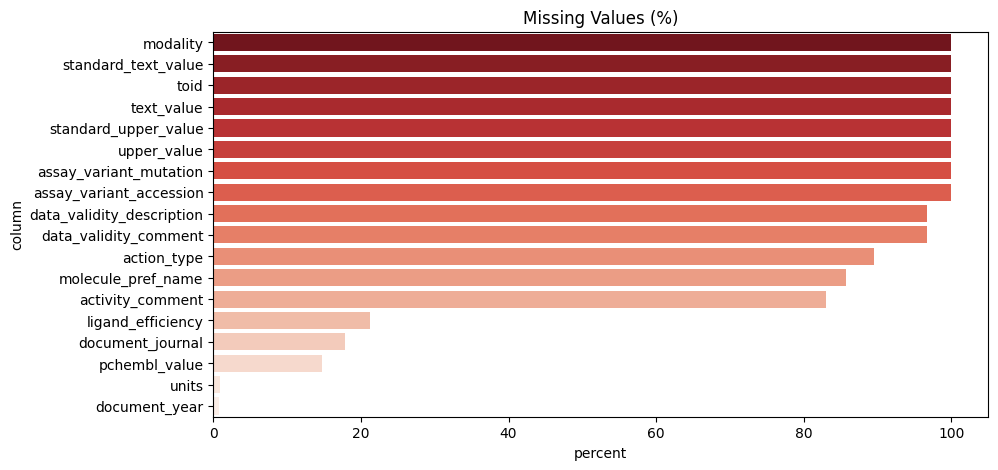

In [4]:
df_raw = pl.read_parquet(INPUT_FILE)
inspect_basic_stats(df_raw)
check_missing_values(df_raw)
plot_missing_values(df_raw)

In [5]:
# TRANSFORMATION FUNCTIONS

def unpack_struct_columns(df: pl.DataFrame) -> pl.DataFrame:
    """Expands struct columns into individual columns (Polars native unnesting)."""
    struct_cols = [col for col, dtype in zip(df.columns, df.dtypes) if isinstance(dtype, pl.Struct)]
    if not struct_cols:
        return df
    
    for col in struct_cols:
        print(f"-> Unnesting struct: {col}")
        df = df.unnest(col)
    return df

def convert_to_numeric(df: pl.DataFrame) -> pl.DataFrame:
    for col in df.columns:
        if df[col].dtype == pl.Utf8:
            attempt = df[col].cast(pl.Float64, strict=False)
            if attempt.null_count() < df.height:
                df = df.with_columns(attempt.alias(col))
    return df

def encode_one_hot(df: pl.DataFrame, max_cardinality=15) -> pl.DataFrame:
    """Performs One-Hot Encoding for low-cardinality string columns."""
    cat_cols = [col for col, dtype in zip(df.columns, df.dtypes) 
                if dtype == pl.Utf8 and df[col].n_unique() <= max_cardinality]
    
    if cat_cols:
        print(f"-> Encoding One-Hot: {cat_cols}")
        df = df.to_dummies(columns=cat_cols)
    return df

def ECFP_from_smiles(smiles, 
                     R = 2, 
                     L = 1024, 
                     use_features = False, 
                     use_chirality = True): # true
    
    if smiles is None or not isinstance(smiles, str):
        return [0] * L
        
    molecule = Chem.MolFromSmiles(smiles)
    
    if molecule is None:
        return [0] * L

    feature_list = AllChem.GetMorganFingerprintAsBitVect(
        molecule,
        radius = R,
        nBits = L,
        useFeatures = use_features,
        useChirality = use_chirality
    )
    
    return list(feature_list)

In [6]:
df = df_raw.filter(
    (pl.col("standard_relation") == "=") &
    (pl.col("standard_units") == "nM") &
    (pl.col("standard_type") == "IC50") &
    (pl.col("assay_type") == "B") &
    (pl.col("target_organism") == "Homo sapiens")
).with_columns(
    pIC50 = 9 - pl.col("standard_value").log10()
).filter(
    pl.col("pIC50").is_between(3, 11)
)

print(f"-> Po filtrze jakości: {df.height} z {df_raw.height} wierszy ({df.height/df_raw.height:.1%})")

print("Rozkład assay_type po filtracji:")
print(df["assay_type"].value_counts())

-> Po filtrze jakości: 1112 z 1381 wierszy (80.5%)
Rozkład assay_type po filtracji:
shape: (1, 2)
┌────────────┬───────┐
│ assay_type ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ B          ┆ 1112  │
└────────────┴───────┘


In [7]:
# Structure Unpacking & Deduplication
df = unpack_struct_columns(df)

# Deduplikacja na poziomie pomiaru, nie cząsteczki
pre_dedup = df.height
df = df.unique(subset=["molecule_chembl_id", "standard_value", "assay_chembl_id", "document_chembl_id"])
print(f"Usunięto duplikaty pomiarów: {pre_dedup - df.height}")

# Numeric Cleaning - bez one-hot na tym etapie
df = convert_to_numeric(df)
# encode_one_hot pomijamy - generuje setki kolumn z szumem

-> Unnesting struct: action_type
-> Unnesting struct: ligand_efficiency
-> Unnesting struct: molecule_properties
Usunięto duplikaty pomiarów: 30


In [8]:
def identify_low_info_columns(
    df: pl.DataFrame, 
    cardinality_threshold: float = 0.99, 
    null_threshold: float = 0.9,
    protected_cols: List[str] = None
) -> List[str]:
    
    if protected_cols is None:
        protected_cols = ["canonical_smiles", "molecule_chembl_id", "standard_units"]
        
    n_rows = df.height
    useless = []

    for col in df.columns:
        dtype = df[col].dtype
        
        # for nested data
        if isinstance(dtype, (pl.List, pl.Struct)):
            useless.append(col)
            continue
            
        n_unique = df[col].n_unique()
        null_count = df[col].null_count()
        
        if n_unique <= 1:
            useless.append(col)
            continue

        if dtype == pl.Utf8 and col not in protected_cols:
            if n_unique > n_rows * cardinality_threshold:
                useless.append(col)
                continue

        if (null_count / n_rows) > null_threshold:
            useless.append(col)

    return useless

In [9]:
low_info_columns = identify_low_info_columns(df)
df = df.drop(low_info_columns)
df.shape

(1082, 44)

In [10]:
cols_to_keep = {
        "molecule_chembl_id", 
        "canonical_smiles", 
        "standard_value", 
        "standard_units",
        "mw_freebase", 
        "alogp", 
        "hba", 
        "hbd", 
        "psa", 
        "rtb", 
        "aromatic_rings", 
        "heavy_atoms", 
        "qed_weighted",
        "ecfp_smiles"
    }

cols = list(cols_to_keep.intersection(set(df.columns)))
df = df.select(cols)
df

canonical_smiles,heavy_atoms,mw_freebase,aromatic_rings,standard_value,hbd,qed_weighted,molecule_chembl_id,hba,alogp,rtb,psa
str,i64,f64,i64,f64,i64,f64,str,i64,f64,i64,f64
"""NS(=O)(=O)c1cc2c(s1)S(=O)(=O)C…",16,283.35,1,10.0,2,0.69,"""CHEMBL348573""",6,-0.91,1,114.53
"""COc1ccccc1/C=C/C(=O)N[C@@H]1[C…",37,552.63,2,53.0,7,0.16,"""CHEMBL4090618""",9,-0.73,8,192.47
"""Cc1nnn(Cc2cc(C(F)(F)F)ccc2CCC(…",43,646.69,3,7.1,1,0.33,"""CHEMBL5841696""",9,2.87,10,158.21
"""CC(C)CN[C@H]1CCS(=O)(=O)c2sc(S…",20,338.48,1,1.2,2,0.85,"""CHEMBL417975""",6,0.86,4,106.33
"""NS(=O)(=O)c1ccc(C(=O)N2NC(=O)c…",28,395.4,3,10.14,2,0.63,"""CHEMBL5196628""",5,1.43,2,126.64
…,…,…,…,…,…,…,…,…,…,…,…
"""Cl.NS(=O)(=O)c1cc(C(=O)c2cccc(…",24,366.46,2,5.0,1,0.81,"""CHEMBL555355""",6,1.46,5,89.7
"""O.O=P(O)(O)C(O)(Cn1ccnc1)P(=O)…",16,272.09,1,62.0,5,0.43,"""CHEMBL4303669""",5,-1.12,4,153.11
"""NS(=O)(=O)c1ccc(C(=O)N[C@@H]2O…",24,362.36,1,9.0,6,0.33,"""CHEMBL4865818""",8,-3.14,4,179.41


Shape: (1082, 12)
Rows: 1082
Columns: 12
$ canonical_smiles   <str> 'NS(=O)(=O)c1cc2c(s1)S(=O)(=O)CC(O)C2', 'COc1ccccc1/C=C/C(=O)N[C@@H]1[C@@H](O)[C@H](O)[C@@H](CO)O[C@H]1NC(=S)Nc1ccc(S(N)(=O)=O)cc1', 'Cc1nnn(Cc2cc(C(F)(F)F)ccc2CCC(=O)N2CCC(CCS(=O)(=O)c3ccc(S(N)(=O)=O)cc3F)CC2)n1', 'CC(C)CN[C@H]1CCS(=O)(=O)c2sc(S(N)(=O)=O)cc21', 'NS(=O)(=O)c1ccc(C(=O)N2NC(=O)c3cccc4cccc(c34)C2=O)cc1', 'NS(=O)(=O)c1cc2c(s1)S(=O)(=O)C(CCN1CCOCC1)CN2', 'NS(=O)(=O)c1ccc(C(=O)n2[nH]c(=O)c3ccc(C(=O)O)cc3c2=O)cc1', 'NS(=O)(=O)c1nnc(NC(=O)c2nn(-c3cccc(/N=N/C(C(=O)c4ccccc4)C(=O)c4ccccc4)c3)c(-c3ccccc3)c2C(=O)c2ccccc2)s1', 'CCOC(=O)c1c(C(=O)Nc2nnc(S(N)(=O)=O)s2)nn(-c2cccc(N)c2)c1-c1ccccc1', 'CC(C)CNCc1cccc(S(=O)(=O)c2csc(S(N)(=O)=O)c2)c1.Cl'
$ heavy_atoms        <i64> 16, 37, 43, 20, 28, 23, 27, 56, 35, 24
$ mw_freebase        <f64> 283.35, 552.63, 646.69, 338.48, 395.4, 381.5, 389.35, 780.85, 513.56, 388.54
$ aromatic_rings     <i64> 1, 2, 3, 1, 3, 1, 3, 7, 4, 2
$ standard_value     <f64> 10.0, 53.0, 7.1, 1.2, 

C:\Users\User\AppData\Local\Temp\ipykernel_19968\698661514.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="percent", y="column", data=null_counts, palette="Reds_r")


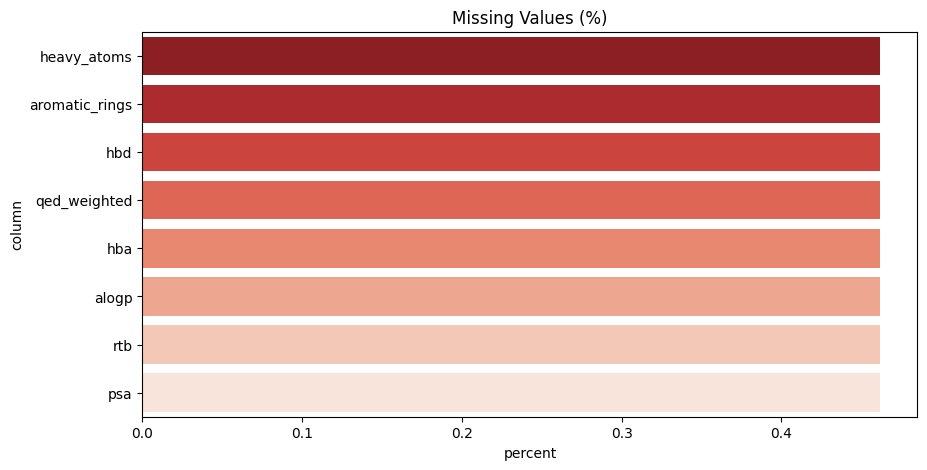

In [11]:
inspect_basic_stats(df)
check_missing_values(df)
plot_missing_values(df)

Rows before aggregation: 1082
Rows after aggregation (Unique Molecules): 838
Średnia liczba pomiarów per cząsteczka: 1.3
Shape: (838, 14)
Rows: 838
Columns: 14
$ molecule_chembl_id <str> 'CHEMBL5897197', 'CHEMBL2408083', 'CHEMBL4861346', 'CHEMBL2392429', 'CHEMBL2336906', 'CHEMBL554042', 'CHEMBL2408085', 'CHEMBL545239', 'CHEMBL3092999', 'CHEMBL3402253'
$ pIC50              <f64> 6.102372908709558, 6.761953896871205, 6.448794056252094, 7.469544156415324, 7.5718652059712115, 8.643974142806877, 7.200659450546419, 8.6167935764438, 4.070581074285708, 6.919734372660155
$ pIC50_std          <f64> 0.0, None, None, None, None, None, None, 0.678987176107412, None, None
$ n_measurements     <u32> 2, 1, 1, 1, 1, 1, 1, 2, 1, 1
$ canonical_smiles   <str> 'Nc1ncnc2c1c(C#Cc1c(F)cccc1OCC(F)(F)F)cn2[C@@H]1O[C@H](CNS(N)(=O)=O)[C@@H](O)[C@H]1O', 'Cc1cc(C)nc(NS(=O)(=O)c2ccc(/N=C/c3c(Cl)c4cc(C(C)(C)C)cc(C(C)(C)C)c4oc3=O)cc2)n1', 'COc1cc2ncnc(Nc3ccc(Cl)c(C(F)(F)F)c3)c2cc1OCCCCC(=O)Nc1ccc(S(N)(=O)=O)cc1', 'NS(

C:\Users\User\AppData\Local\Temp\ipykernel_19968\698661514.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="percent", y="column", data=null_counts, palette="Reds_r")


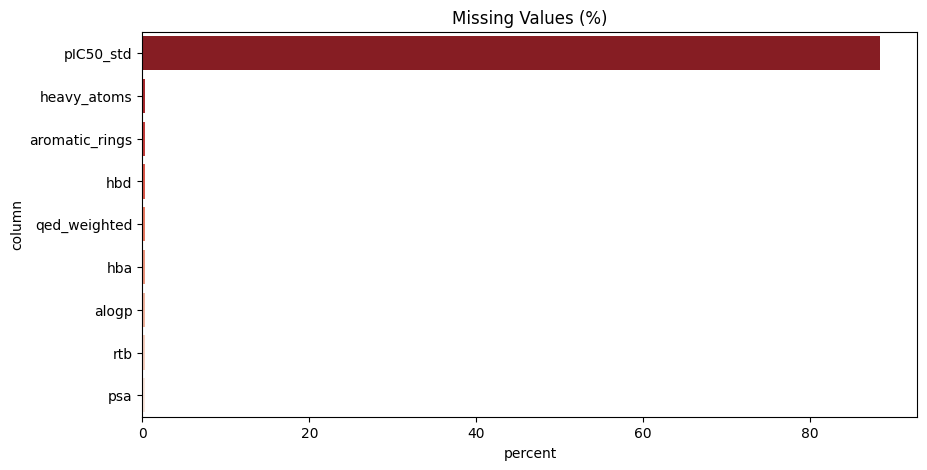

In [12]:
df = df.with_columns(pl.col("standard_value").cast(pl.Float64))
df = df.filter(pl.col("standard_value") > 0)
df = df.with_columns(
        (9 - pl.col("standard_value").log10()).alias("pIC50")
    )

df = df.filter(pl.col("pIC50").is_between(3.0, 11.0))

print(f"Rows before aggregation: {df.height}")

df = df.with_columns(
    pl.col("pIC50").median().over("molecule_chembl_id").alias("pIC50_med")
)
df = df.filter((pl.col("pIC50") - pl.col("pIC50_med")).abs() <= 2.5).drop("pIC50_med")

# Define aggregation
group_col = "molecule_chembl_id"
exclude_cols = {group_col, "pIC50", "standard_value", "standard_units"}
static_cols = [c for c in df.columns if c not in exclude_cols]

agg_exprs = [
    pl.col("pIC50").median(),
    pl.col("pIC50").std().alias("pIC50_std"),
    pl.col("pIC50").count().alias("n_measurements")
] + [pl.col(c).first() for c in static_cols]

df = df.group_by(group_col).agg(agg_exprs)

df = df.filter((pl.col("pIC50_std") < 1.0) | pl.col("pIC50_std").is_null())

print(f"Rows after aggregation (Unique Molecules): {df.height}")
print(f"Średnia liczba pomiarów per cząsteczka: {df['n_measurements'].mean():.1f}")

inspect_basic_stats(df)
check_missing_values(df)
plot_missing_values(df)

In [13]:
# ANALYSIS & VISUALIZATION

def impute_iterative_sklearn(df: pl.DataFrame) -> pl.DataFrame:
    numeric_selectors = [pl.Float64, pl.Int64, pl.Float32, pl.Int32]
    num_cols = df.select(pl.col(numeric_selectors)).columns
    
    if not num_cols:
        return df

    matrix = df.select(num_cols).to_numpy()
    imp = IterativeImputer(max_iter=10)
    matrix_imputed = imp.fit_transform(matrix)
    updated_columns = [
        pl.Series(name, matrix_imputed[:, i]) 
        for i, name in enumerate(num_cols)
    ]
    
    return df.with_columns(updated_columns)

def analyze_correlation(df: pl.DataFrame, threshold=0.8) -> pl.DataFrame:
    """Calculates correlation matrix and drops redundant features."""
    num_df = df.select(pl.col(pl.Float64, pl.Int64))
    if num_df.width < 2:
        return df

    corr_matrix = num_df.corr()
    cols = corr_matrix.columns
    to_drop = []

    # Iterate through correlation matrix
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = corr_matrix[cols[i]][j]
            if abs(val) > threshold:
                # Protect target variables
                if cols[j] not in ['pIC50', 'standard_value']:
                    to_drop.append(cols[j])

    unique_drops = list(set(to_drop))
    print(f"-> Dropping {len(unique_drops)} highly correlated columns: {unique_drops}")
    
    # Visualization (Transfer to Pandas only for plotting)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix.to_pandas(), cmap="coolwarm", xticklabels=cols, yticklabels=cols)
    plt.title("Correlation Matrix")
    plt.show()

    return df.drop(unique_drops)

def plot_all_distributions(df: pl.DataFrame):
    num_cols = [c for c, t in zip(df.columns, df.dtypes) 
                if t in [pl.Float64, pl.Int64] and df[c].n_unique() > 2]
    if not num_cols: return
    
    c_grid = 3
    r_grid = (len(num_cols) // c_grid) + (1 if len(num_cols) % c_grid > 0 else 0)
    plt.figure(figsize=(15, 4 * r_grid))
    for i, col in enumerate(num_cols):
        plt.subplot(r_grid, c_grid, i + 1)
        sns.histplot(df[col].to_pandas(), kde=False)
        plt.title(col)
    plt.tight_layout()
    plt.show()

-> Dropping 1 highly correlated columns: ['mw_freebase']


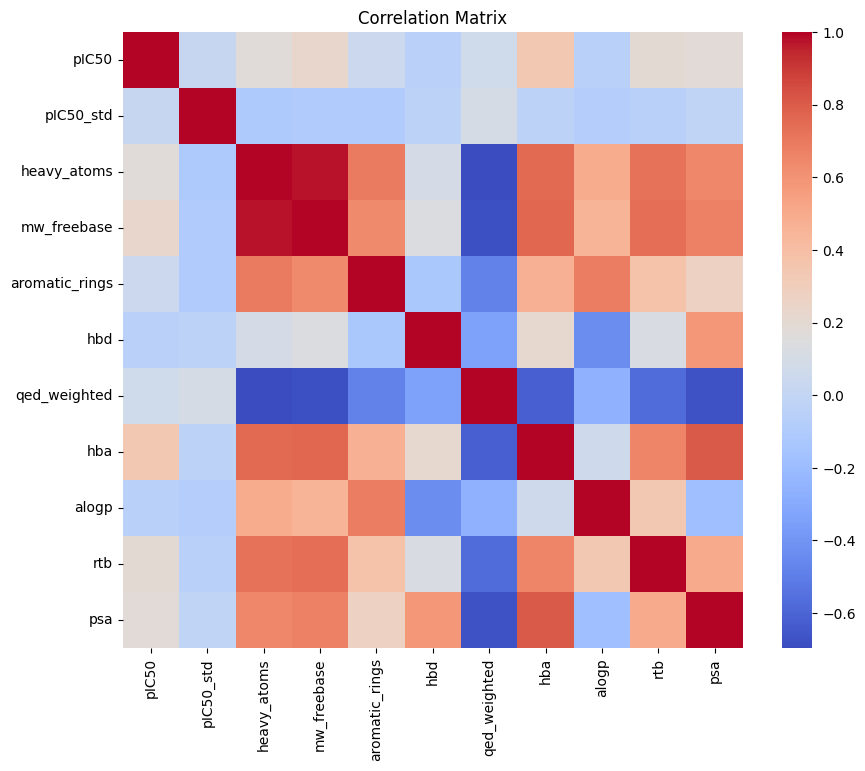

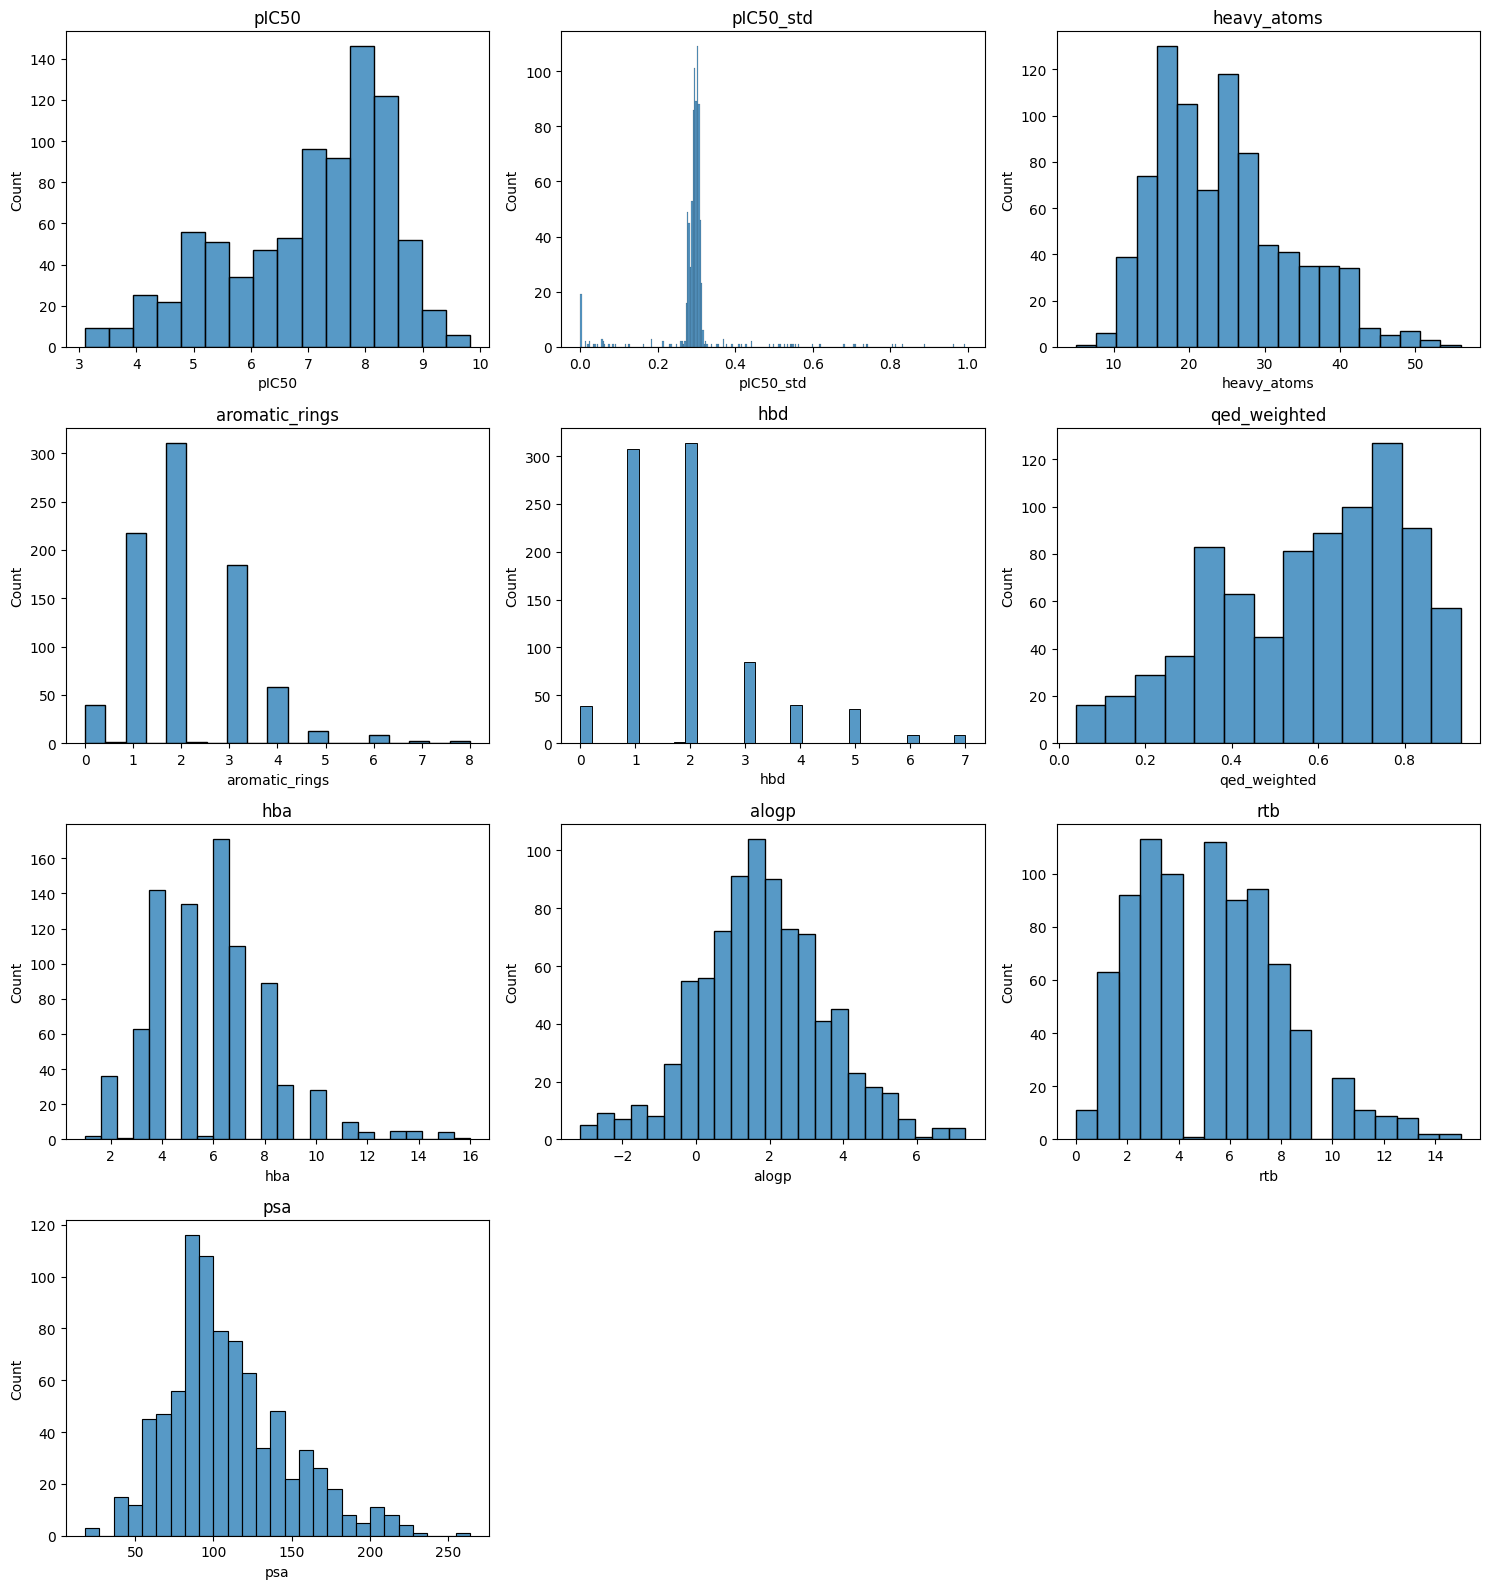

In [14]:
df = impute_iterative_sklearn(df)
df = analyze_correlation(df, threshold=0.9)
plot_all_distributions(df)

In [15]:
def analyze_outliers_iqr(df: pl.DataFrame, factor: float = 1.5) -> pl.DataFrame:
    """Calculates IQR statistics and outlier counts for numeric features."""
    numeric_cols = [c for c, t in zip(df.columns, df.dtypes) if t in [pl.Float64, pl.Int64]]
    report_data = []

    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        
        if q1 is None or q3 is None:
            continue
            
        iqr = q3 - q1
        lower_bound = q1 - (factor * iqr)
        upper_bound = q3 + (factor * iqr)
        
        outlier_count = df.filter(
            (pl.col(col) < lower_bound) | (pl.col(col) > upper_bound)
        ).height
        
        report_data.append({
            "Feature": col,
            "IQR": iqr,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outliers": outlier_count,
            "Outliers_Pct": round((outlier_count / df.height) * 100, 2)
        })
        
    return pl.DataFrame(report_data).sort("Outliers_Pct", descending=True)

def plot_boxplots_grid(df: pl.DataFrame):
    """Generates a grid of boxplots for all numeric features."""
    numeric_cols = [c for c, t in zip(df.columns, df.dtypes) if t in [pl.Float64, pl.Int64]]
    if not numeric_cols:
        return

    n_plots = len(numeric_cols)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)
    
    # Convert to pandas once for visualization efficiency
    pdf = df.select(numeric_cols).to_pandas()
    
    plt.figure(figsize=(16, 4 * n_rows))
    for i, col in enumerate(numeric_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(x=pdf[col], color="#4C72B0")
        plt.title(col, fontweight='bold')
        plt.xlabel("")
        
    plt.tight_layout()
    plt.show()

shape: (10, 6)
┌────────────────┬──────────┬─────────────┬─────────────┬──────────┬──────────────┐
│ Feature        ┆ IQR      ┆ Lower_Bound ┆ Upper_Bound ┆ Outliers ┆ Outliers_Pct │
│ ---            ┆ ---      ┆ ---         ┆ ---         ┆ ---      ┆ ---          │
│ str            ┆ f64      ┆ f64         ┆ f64         ┆ i64      ┆ f64          │
╞════════════════╪══════════╪═════════════╪═════════════╪══════════╪══════════════╡
│ hbd            ┆ 1.0      ┆ -0.5        ┆ 3.5         ┆ 92       ┆ 10.98        │
│ pIC50_std      ┆ 0.017015 ┆ 0.261095    ┆ 0.329154    ┆ 89       ┆ 10.62        │
│ psa            ┆ 43.62    ┆ 20.75       ┆ 195.23      ┆ 26       ┆ 3.1          │
│ hba            ┆ 3.0      ┆ -0.5        ┆ 11.5        ┆ 19       ┆ 2.27         │
│ alogp          ┆ 2.2      ┆ -2.58       ┆ 6.22        ┆ 15       ┆ 1.79         │
│ heavy_atoms    ┆ 13.0     ┆ -2.5        ┆ 49.5        ┆ 8        ┆ 0.95         │
│ aromatic_rings ┆ 2.0      ┆ -2.0        ┆ 6.0         ┆ 4  

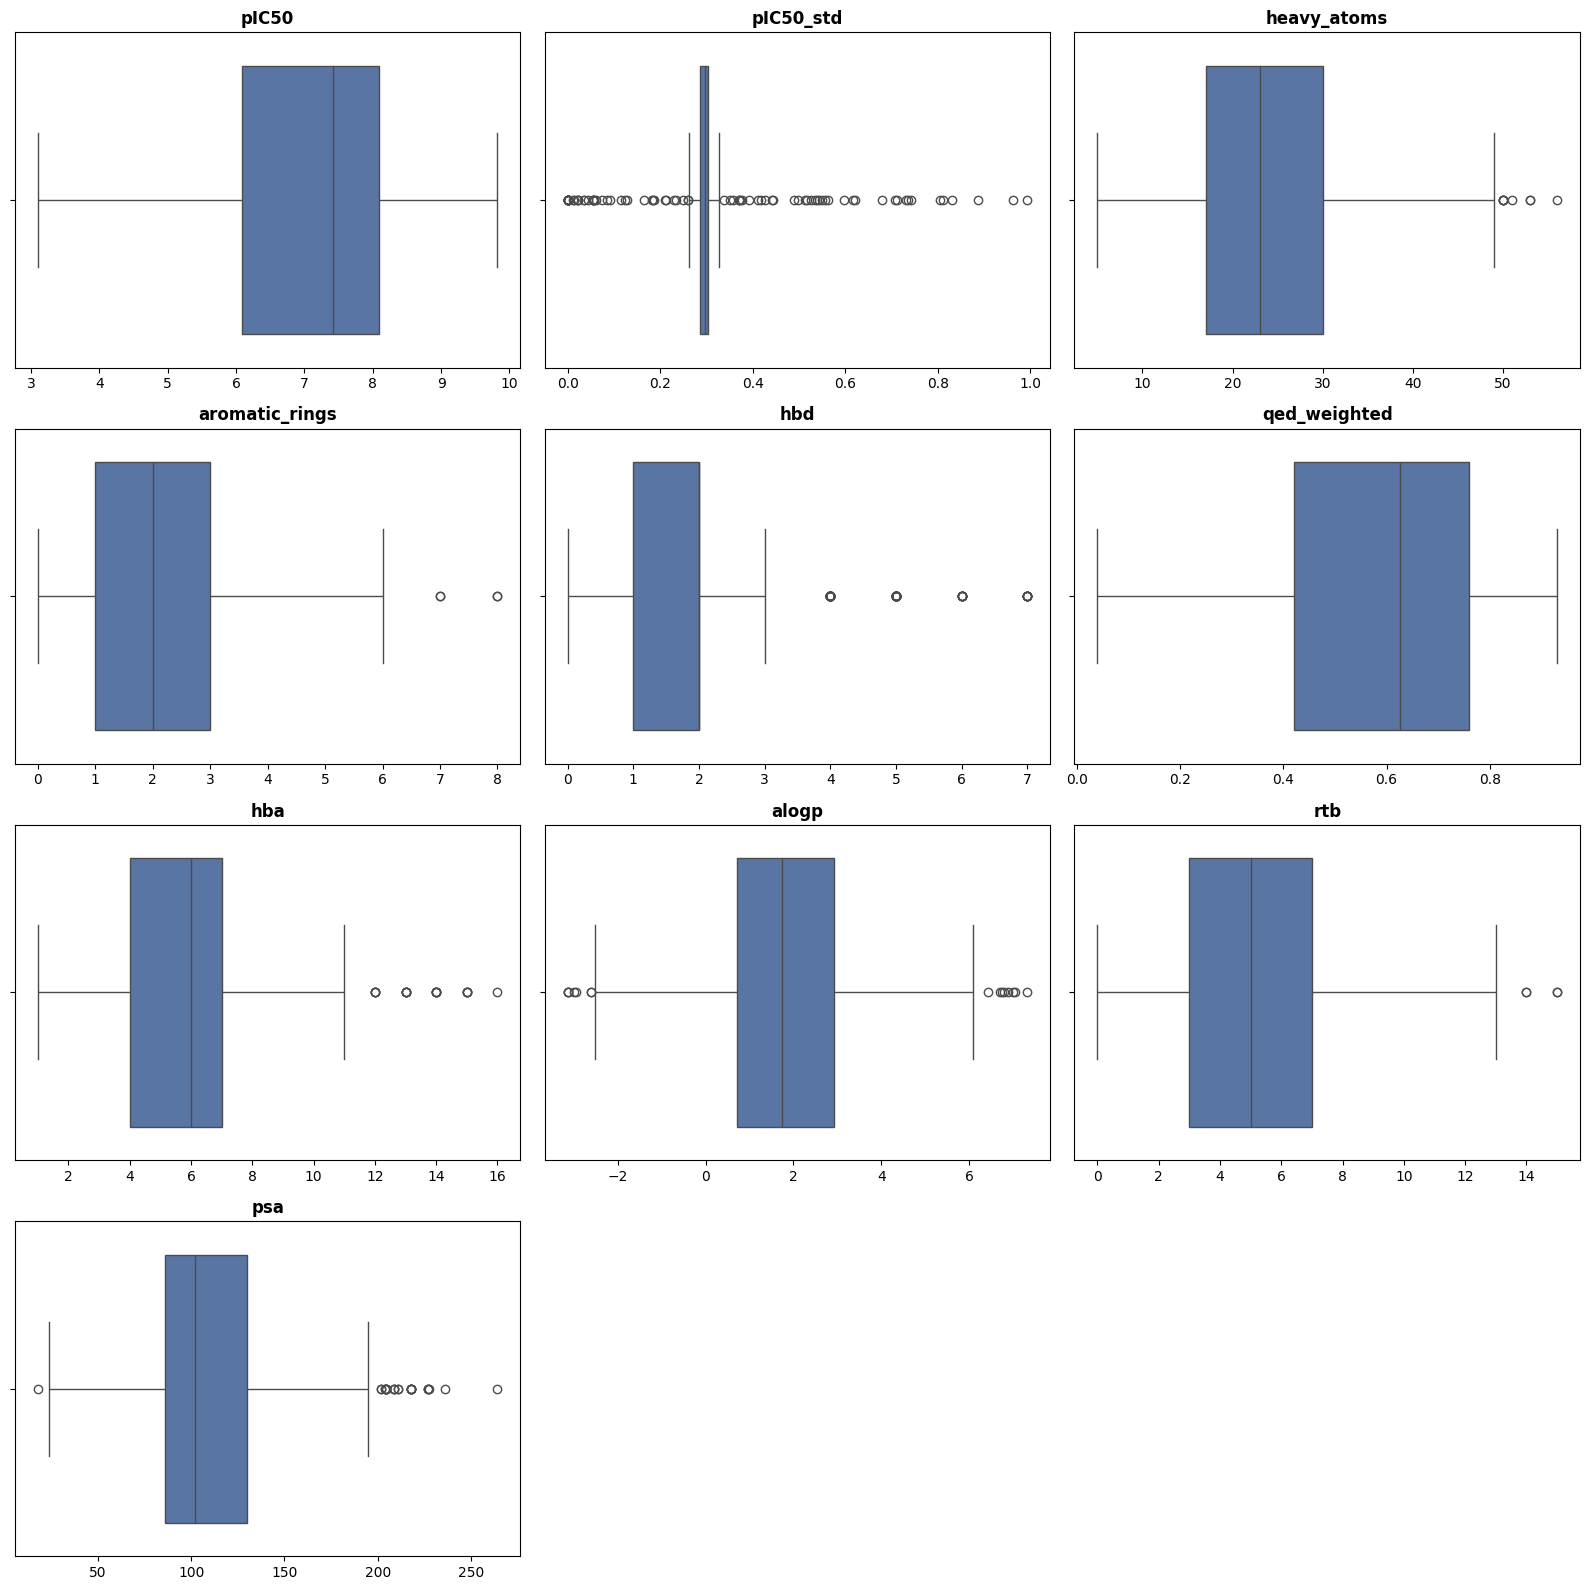

In [16]:
# here we will begin to introduce dataset versioning
outlier_report = analyze_outliers_iqr(df)
print(outlier_report)

q1 = df["pIC50"].quantile(0.25)
q3 = df["pIC50"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
before = df.height
df = df.filter(pl.col("pIC50").is_between(lower, upper))
print(f"Usunięto outliery pIC50 poza [{lower:.2f}, {upper:.2f}]: {before - df.height}")

plot_boxplots_grid(df)

In [17]:
"""
Analiza Przestrzeni Chemicznej (Chemical Space Analysis)

Analiza Korelacji Fizykochemicznych (X vs Y)

Analiza Różnorodności (Scaffold Analysis)
"""

'\nAnaliza Przestrzeni Chemicznej (Chemical Space Analysis)\n\nAnaliza Korelacji Fizykochemicznych (X vs Y)\n\nAnaliza Różnorodności (Scaffold Analysis)\n'

In [18]:
df

molecule_chembl_id,pIC50,pIC50_std,n_measurements,canonical_smiles,heavy_atoms,aromatic_rings,hbd,qed_weighted,hba,alogp,rtb,psa
str,f64,f64,u32,str,f64,f64,f64,f64,f64,f64,f64,f64
"""CHEMBL5897197""",6.102373,0.0,2,"""Nc1ncnc2c1c(C#Cc1c(F)cccc1OCC(…",38.0,3.0,5.0,0.2,10.0,-0.09,6.0,187.84
"""CHEMBL2408083""",6.761954,0.271879,1,"""Cc1cc(C)nc(NS(=O)(=O)c2ccc(/N=…",40.0,4.0,1.0,0.2,7.0,7.0,5.0,114.52
"""CHEMBL4861346""",6.448794,0.273612,1,"""COc1cc2ncnc(Nc3ccc(Cl)c(C(F)(F…",42.0,4.0,3.0,0.18,8.0,5.89,11.0,145.53
"""CHEMBL2392429""",7.469544,0.298307,1,"""NS(=O)(=O)c1ccc(NC(=O)c2cccc(N…",26.0,2.0,2.0,0.78,5.0,1.24,4.0,126.64
"""CHEMBL2336906""",7.571865,0.293775,1,"""Cc1cc(-c2nnc(Nc3ccc(S(N)(=O)=O…",32.0,4.0,3.0,0.41,7.0,2.64,5.0,158.13
…,…,…,…,…,…,…,…,…,…,…,…,…
"""CHEMBL83165""",8.508638,0.289096,1,"""CCCCCCCCCCCC(=O)Oc1ccc2nc(S(N)…",27.0,2.0,1.0,0.31,6.0,4.77,12.0,99.35
"""CHEMBL164126""",8.045757,0.311375,1,"""Nc1ccc2oc(S(N)(=O)=O)cc2c1""",14.0,2.0,2.0,0.68,4.0,0.66,1.0,99.32
"""CHEMBL42278""",8.69897,0.302934,1,"""CCCCCC/C(=N\N)c1csc(S(N)(=O)=O…",18.0,1.0,2.0,0.35,5.0,2.03,7.0,98.54


## Base Model

In [19]:
# --- 1. FEATURIZATION ---

def smiles_to_ecfp(smiles: str, radius: int = 2, n_bits: int = 2048):
    """Generates Morgan Fingerprint z chiralnością."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits, useChirality=True)
        return list(fp)
    except:
        return None

def get_murcko_scaffold(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=True)
    except:
        return None

def featurize_dataset(df: pl.DataFrame) -> pl.DataFrame:
    print("Generating Fingerprints and Scaffolds...")
    
    df = df.with_columns([
        pl.col("canonical_smiles").map_elements(smiles_to_ecfp, return_dtype=pl.List(pl.Int64)).alias("ecfp_2048"),
        pl.col("canonical_smiles").map_elements(get_murcko_scaffold, return_dtype=pl.Utf8).alias("scaffold")
    ])
    
    # Drop rows where RDKit failed
    return df.drop_nulls(subset=["ecfp_2048", "scaffold"])

# --- 2. SPLITTING STRATEGIES ---

def random_split(df: pl.DataFrame, test_size=0.1, val_size=0.1, random_state=42):
    """Standard Random Split (80/10/10)."""
    pdf = df.to_pandas()
    
    # Val size adjustment relative to remaining data
    val_ratio = val_size / (1.0 - test_size) 
    
    train_val, test = train_test_split(pdf, test_size=test_size, random_state=random_state)
    train, val = train_test_split(train_val, test_size=val_ratio, random_state=random_state)
    
    return pl.from_pandas(train), pl.from_pandas(val), pl.from_pandas(test)

def scaffold_split(df: pl.DataFrame, test_size=0.1, val_size=0.1, seed=7):
    """GroupShuffleSplit - brak przecieku scaffoldów."""
    from sklearn.model_selection import GroupShuffleSplit
    pdf = df.to_pandas()

    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(gss_test.split(pdf, groups=pdf['scaffold']))

    train_val = pdf.iloc[train_val_idx]
    test = pdf.iloc[test_idx]

    val_ratio = val_size / (1.0 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss_val.split(train_val, groups=train_val['scaffold']))

    return pl.from_pandas(train_val.iloc[train_idx]), pl.from_pandas(train_val.iloc[val_idx]), pl.from_pandas(test)



# --- 3. EXECUTION & MLFLOW LOGGING ---

def prepare_and_log_datasets(df_gold: pl.DataFrame, output_dir: str):
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    
    df_features = featurize_dataset(df_gold)
    
    splits = {
        "random": random_split(df_features),
        "scaffold": scaffold_split(df_features)
    }
    
    metadata = {
        "version": DATA_VERSION,
        "timestamp": TIMESTAMP,
        "description": DATA_DESCRIPTION,
        "source_file": str(INPUT_FILE.name),
        "total_rows_after_eda": df_features.height,
        "splits_info": {}
    }
    
    mlflow.set_experiment("ChEMBL_Data_Preparation")
    
    with mlflow.start_run(run_name=f"Dataset_Generation_{DATA_VERSION}"):
        mlflow.log_param("data_version", DATA_VERSION)
        mlflow.log_param("description", DATA_DESCRIPTION)
        mlflow.log_param("n_bits", 2048)
        
        for split_type, (train, val, test) in splits.items():
            print(f"Saving {split_type} split...")
            
            p_train = out_path / f"{split_type}_train.parquet"
            p_val = out_path / f"{split_type}_val.parquet"
            p_test = out_path / f"{split_type}_test.parquet"
            
            train.write_parquet(p_train)
            val.write_parquet(p_val)
            test.write_parquet(p_test)
            
            metadata["splits_info"][split_type] = {
                "train_size": train.height,
                "val_size": val.height,
                "test_size": test.height
            }
            
            mlflow.log_metric(f"{split_type}_train_size", train.height)
            mlflow.log_metric(f"{split_type}_val_size", val.height)
            mlflow.log_metric(f"{split_type}_test_size", test.height)
            
            mlflow.log_artifact(str(p_train), artifact_path=f"datasets/{split_type}")
            mlflow.log_artifact(str(p_val), artifact_path=f"datasets/{split_type}")
            mlflow.log_artifact(str(p_test), artifact_path=f"datasets/{split_type}")
            
        meta_file = out_path / "metadata.json"
        with open(meta_file, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=4, ensure_ascii=False)
            
        mlflow.log_artifact(str(meta_file), artifact_path="dataset_metadata")
            
    print(f"\nDatasets prepared and logged to MLflow. Metadata saved in {meta_file.name}")

prepare_and_log_datasets(df, OUTPUT_DIR)

Generating Fingerprints and Scaffolds...
Saving random split...
Saving scaffold split...


2026/06/06 15:20:45 INFO mlflow.tracking._tracking_service.client: 🏃 View run Dataset_Generation_v3.0_205 at: http://localhost:5000/#/experiments/3/runs/9f0fb4e144244480b3286b2fde134119.
2026/06/06 15:20:45 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/3.



Datasets prepared and logged to MLflow. Metadata saved in metadata.json


In [20]:
# --- 1. DATASET DEFINITION ---

class QsARDataset(Dataset):
    """PyTorch Dataset for QSAR regression tasks using ECFP fingerprints."""
    
    def __init__(self, parquet_path: Union[str, Path]):
        print(f"Loading data from: {parquet_path}")
        
        df = pl.read_parquet(parquet_path).select(["ecfp_2048", "pIC50"])
        
        self.X = torch.tensor(df["ecfp_2048"].to_list(), dtype=torch.float32)
        self.y = torch.tensor(df["pIC50"].to_numpy(), dtype=torch.float32).view(-1, 1)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]

# --- 2. MODEL ARCHITECTURE ---

class MLPBaseline(nn.Module):
    def __init__(self, input_dim: int = 2048, dropout_rate: float = 0.15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.network(x)

# --- 3. TRAINING FUNCTION ---

def train_model(train_loader, val_loader, epochs=100, lr=3e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLPBaseline().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    criterion = nn.SmoothL1Loss()

    mlflow.set_experiment("QSAR_MLP_Baseline")
    with mlflow.start_run(run_name="MLP_2048_v2"):
        best_val = float('inf')
        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for X,y in train_loader:
                X,y = X.to(device), y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()*X.size(0)
            
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for X,y in val_loader:
                    X,y = X.to(device), y.to(device)
                    val_loss += criterion(model(X), y).item()*X.size(0)
            
            avg_train = train_loss/len(train_loader.dataset)
            avg_val = val_loss/len(val_loader.dataset)
            scheduler.step(avg_val)
            
            if avg_val < best_val:
                best_val = avg_val
                torch.save(model.state_dict(), "best_mlp.pt")
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch:03d}: Train {avg_train:.4f} | Val {avg_val:.4f}")
        
        mlflow.pytorch.log_model(model, "model")
    
    model.load_state_dict(torch.load("best_mlp.pt"))
    return model


In [21]:
# Initialization
def get_latest_valid_version(base_path: Union[str, Path], prefix: str = "version_v1.2") -> Path:
    base_path = Path(base_path)
    
    subdirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith(prefix)]
    
    subdirs.sort(key=lambda d: d.name, reverse=True)

    for subdir in subdirs:
        train_file = subdir / "scaffold_train.parquet"
        val_file = subdir / "scaffold_val.parquet"
        
        if train_file.exists() and val_file.exists():
            return subdir

LATEST_DATA_PATH = get_latest_valid_version(GOLD_DIR, prefix=f"version_{DATA_VERSION}")

train_dataset = QsARDataset(LATEST_DATA_PATH / "scaffold_train.parquet")
val_dataset = QsARDataset(LATEST_DATA_PATH / "scaffold_val.parquet")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loading data from: C:\Users\User\Desktop\spark_airflow\chembl\dags\data\gold\version_v3.0_205_20260606_1520\scaffold_train.parquet
Loading data from: C:\Users\User\Desktop\spark_airflow\chembl\dags\data\gold\version_v3.0_205_20260606_1520\scaffold_val.parquet
Train batches: 6 | Val batches: 1


Epoch 000: Train 6.1398 | Val 5.8605
Epoch 010: Train 1.5506 | Val 3.0014
Epoch 020: Train 0.3509 | Val 1.3244


2026/06/06 15:21:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/06 15:21:04 INFO mlflow.tracking._tracking_service.client: 🏃 View run MLP_2048_v2 at: http://localhost:5000/#/experiments/4/runs/d96bd27665944f1ca5185da7515163b8.
2026/06/06 15:21:04 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/4.
C:\Users\User\AppData\Local\Temp\ipykernel_19968\3961887398.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This li


Validation RMSE: 1.0819


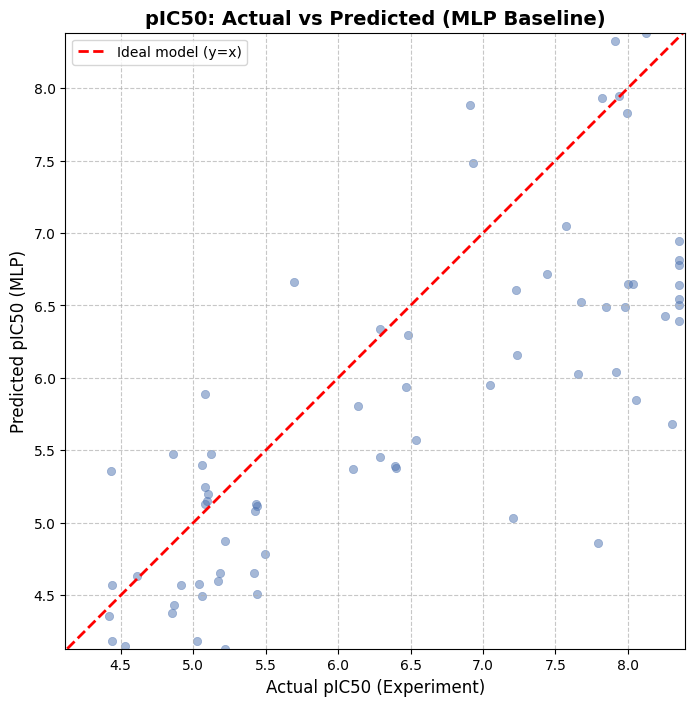

In [22]:
trained_model = train_model(train_loader, val_loader, epochs=30, lr=1e-3)

def evaluate_and_plot(model: torch.nn.Module, loader: DataLoader):
    """Generates predictions and plots Actual vs Predicted pIC50."""
    model.eval()
    device = torch.device("cpu")
    model = model.to(device)
    
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            
            y_true.extend(y_batch.numpy().flatten())
            y_pred.extend(preds.numpy().flatten())
            
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    print(f"\nValidation RMSE: {rmse:.4f}")
    
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color="#4C72B0", edgecolor=None)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Ideal model (y=x)")
    
    plt.title("pIC50: Actual vs Predicted (MLP Baseline)", fontsize=14, fontweight='bold')
    plt.xlabel("Actual pIC50 (Experiment)", fontsize=12)
    plt.ylabel("Predicted pIC50 (MLP)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.axis('equal')
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.show()

evaluate_and_plot(trained_model, val_loader)

In [23]:
test_dataset = QsARDataset(LATEST_DATA_PATH / "scaffold_test.parquet")
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

def evaluate_test_set(model: torch.nn.Module, loader: DataLoader):
    model.eval()
    device = torch.device("cpu")
    model = model.to(device)
    
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            y_true.extend(y_batch.numpy().flatten())
            y_pred.extend(preds.numpy().flatten())
            
    rmse = np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))
    print(f"Final Test RMSE: {rmse:.4f}")

evaluate_test_set(trained_model, test_loader)

Loading data from: C:\Users\User\Desktop\spark_airflow\chembl\dags\data\gold\version_v3.0_205_20260606_1520\scaffold_test.parquet
Final Test RMSE: 1.7086
